# Modelo de previsão de sentimento em texto Gemini:

Neste modelo, foi utilizado a Regressão Logística para classificar sentimentos em avaliações do Gemini (positivo ou negativo). Após ler o arquivo CSV, transformamos o texto em vetores numéricos usando TF-IDF, removendo palavras comuns (stop words) em português. Dividimos os dados em treino e teste e treinamos o modelo de regressão logística. O objetivo é prever sentimentos nas avaliações e, em seguida, comparar as previsões com as classes verdadeiras, utilizando métricas como acurácia e matriz de confusão para avaliar o desempenho.

In [107]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import re
import nltk
from nltk.corpus import stopwords
import seaborn as sns

**Preparação dos dados:**
1. Certificado se a coluna de avaliações está disponível e devidamente rotulada (ex.: sentimentos positivo, negativo ou neutro).

2. Removido ruídos e padrões não textuais (como URLs, números, pontuação irrelevante).

3. Quebrado as avaliações em tokens (palavras ou sub-palavras), que serão a base do processamento.

4. Removido palavras comuns que não agregam significado, como “de”, “a”, “e”, etc.

In [108]:
df = pd.read_csv('gemini.csv', sep=',', engine='python', quotechar='"', on_bad_lines='skip')

In [109]:
df

,texto,sentimento
0,O serviço de entrega foi incrivelmente rápido ...,POSITIVO
1,O café da manhã não tinha muitas opções quentes.,NEGATIVO
2,A reunião está agendada para as dez horas da m...,NEUTRO
3,Fiquei extremamente desapontado com a qualidad...,NEGATIVO
4,Recebi um elogio maravilhoso da minha equipe h...,POSITIVO
...,...,...
1195,A reunião foi adiada para a próxima semana.,NEUTRO
1196,A falta de perspectiva me causa um sofrimento ...,NEGATIVO
1197,A atitude de bondade dele me tocou profundamente.,POSITIVO
1198,"O valor do curso é de R$ 500,00.",NEUTRO


**Detalhamento das colunas do Dataset:**

- **Texto:** Nesta coluna estão o comentário de vários clientes sobre o aplicativo Gemini.

- **Sentimento:** Coluna que demostra uma análise sentimental, avaliando o comentário dos clientes em Positivo e Negativo.

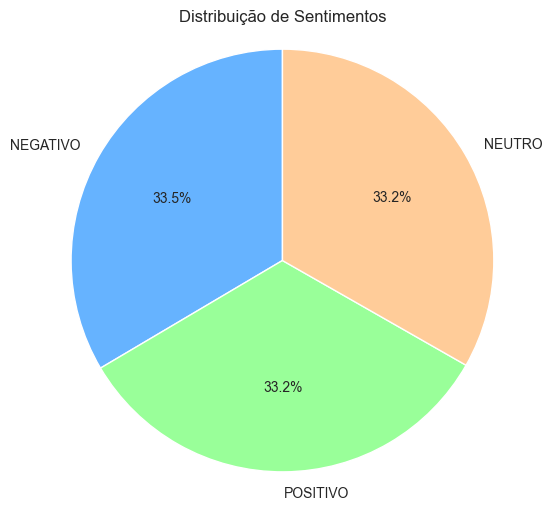

In [110]:
#Plotando um gráfico de setor para verificarmos a distribuição das classes
sentiment_counts = df['sentimento'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99','#ffcc99'])
plt.title('Distribuição de Sentimentos')
plt.axis('equal')
plt.show()

**Limpeza e tratamento:**

Nesta etapa foram removidos números, pontuações, espaços extras e stopwords. Após a conclusão da limpeza e do tratamento dos dados, foi apresentado um exemplo comparando como as frases estavam antes e como ficaram após o processamento.

In [111]:
nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese'))

def limpar_texto(texto):

    # remover números
    texto = re.sub(r'\d+', '', texto)

    # remover pontuação
    texto = re.sub(r'[^\w\s]','', texto)

    # remover espaços extras
    texto = texto.strip()

    # remover stopwords
    stop_words.update('de', 'a', 'A','O', 'o', 'e', 'um', 'uma', 'que', 'em', 'os', 'para', 'na', 'no','com', 'é', 'do', 'da', 'dos', 'das', 'se', 'ou', 'mas', 'está')

    palavras = texto.split()
    palavras = [p for p in palavras if p not in stop_words]

    return " ".join(palavras)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [112]:
df["texto_limpo"] = df["texto"].apply(limpar_texto)

In [113]:
print("Original:", df["texto"][0])
print("Limpo:", df["texto_limpo"][0])

Original: O serviço de entrega foi incrivelmente rápido e eficiente.
Limpo: serviço entrega incrivelmente rápido eficiente


In [114]:
df.head()

,texto,sentimento,texto_limpo
0,O serviço de entrega foi incrivelmente rápido ...,POSITIVO,serviço entrega incrivelmente rápido eficiente
1,O café da manhã não tinha muitas opções quentes.,NEGATIVO,café manhã muitas opções quentes
2,A reunião está agendada para as dez horas da m...,NEUTRO,reunião agendada dez horas manhã
3,Fiquei extremamente desapontado com a qualidad...,NEGATIVO,Fiquei extremamente desapontado qualidade fina...
4,Recebi um elogio maravilhoso da minha equipe h...,POSITIVO,Recebi elogio maravilhoso equipe hoje


In [115]:
df = df.drop(columns=['texto'])

In [116]:
df.head()

,sentimento,texto_limpo
0,POSITIVO,serviço entrega incrivelmente rápido eficiente
1,NEGATIVO,café manhã muitas opções quentes
2,NEUTRO,reunião agendada dez horas manhã
3,NEGATIVO,Fiquei extremamente desapontado qualidade fina...
4,POSITIVO,Recebi elogio maravilhoso equipe hoje


**Vetorizando com o TF-IDF:**

Antes de treinar o modelo, o texto foi convertido em uma forma que o algoritmo de machine learning consiga entender, utilizando o TF-IDF (Term Frequency-Inverse Document Frequency).

In [117]:
# Criando o vectorized TF-IDF
tfidf = TfidfVectorizer(max_features=5000)  # Usando o max limitando a 5000 palavras mais frequentes para evitar dimensionalidade excessiva

# Aplicando o TF-IDF na coluna de texto
X = tfidf.fit_transform(df['texto_limpo'])  # Transformando as avaliações de texto em uma matriz de características numéricas, visto que em modelos trabalhamos com números

In [118]:
# Obtendo novamente os nomes das palavras
words = tfidf.get_feature_names_out()

# Calculando a média dos valores de aparições de cada palavra
mean_tfidf = X.toarray().mean(axis=0)

# Criando um DataFrame com as palavras e seus valores médios de TF-IDF
tfidf_df = pd.DataFrame(data={'Word': words, 'Mean_TFIDF': mean_tfidf})
tfidf_df = tfidf_df.sort_values(by='Mean_TFIDF', ascending=False)

print(tfidf_df.head(20))

            Word  Mean_TFIDF
829        falta    0.016227
1354        novo    0.014019
296       causou    0.010873
1350        nova    0.010286
1786    sensação    0.010131
1973       valor    0.009564
667          ele    0.009218
1616         que    0.008518
517       deixou    0.008463
1716     reunião    0.008234
1543       preço    0.008127
1684   relatório    0.007837
171      atitude    0.007646
1518       prazo    0.007502
328       cheiro    0.007044
1360      número    0.006507
1556     produto    0.006348
1918    trabalho    0.006202
1181       livro    0.006106
1936  tratamento    0.005869


In [119]:
#  Refazemos o TF-IDF na coluna de texto, removendo as stop words personalizadas
tfidf_2 = TfidfVectorizer(max_features=5000)
X = tfidf_2.fit_transform(df['texto_limpo'])

In [120]:
#Apenas reproduzimos o código rodado anteriormente
words = tfidf_2.get_feature_names_out()
mean_tfidf = X.toarray().mean(axis=0)
tfidf_df = pd.DataFrame(data={'Word': words, 'Mean_TFIDF': mean_tfidf})
tfidf_df = tfidf_df.sort_values(by='Mean_TFIDF', ascending=False)
print(tfidf_df.head(20))

            Word  Mean_TFIDF
829        falta    0.016227
1354        novo    0.014019
296       causou    0.010873
1350        nova    0.010286
1786    sensação    0.010131
1973       valor    0.009564
667          ele    0.009218
1616         que    0.008518
517       deixou    0.008463
1716     reunião    0.008234
1543       preço    0.008127
1684   relatório    0.007837
171      atitude    0.007646
1518       prazo    0.007502
328       cheiro    0.007044
1360      número    0.006507
1556     produto    0.006348
1918    trabalho    0.006202
1181       livro    0.006106
1936  tratamento    0.005869


In [121]:
label_encoder = LabelEncoder()
df['sentimento'] = label_encoder.fit_transform(df['sentimento'])

In [122]:
y = df['sentimento']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% para treino e 20% para teste

In [123]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [124]:
y_pred = model.predict(X_train)

In [125]:
relatorio = classification_report(y_train, y_pred)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00       315
           2       1.00      1.00      1.00       320

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [126]:
y_pred_test = model.predict(X_test)

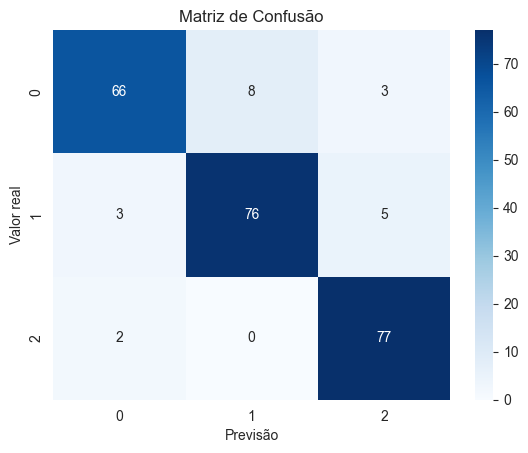

Relatório de Classificação:
Acurácia: 0.912
              precision    recall  f1-score   support
NEGATIVO       0.929577  0.857143  0.891892   77.0000
NEUTRO         0.904762  0.904762  0.904762   84.0000
POSITIVO       0.905882  0.974684  0.939024   79.0000
accuracy       0.912500  0.912500  0.912500    0.9125
macro avg      0.913407  0.912196  0.911893  240.0000
weighted avg   0.913092  0.912500  0.911911  240.0000


In [127]:
# Matriz
cm = confusion_matrix(y_test, y_pred_test)
df_cm = pd.DataFrame(cm,
                     index=["NEGATIVO","NEUTRO","POSITIVO"],
                     columns=["NEGATIVO","NEUTRO","POSITIVO"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Previsão")
plt.ylabel("Valor real")
plt.title("Matriz de Confusão")
plt.show()

print('Relatório de Classificação:')

accuracy = accuracy_score(y_test, y_pred_test)
print(f'Acurácia: {accuracy:.3f}')

class_report = classification_report(
    y_test,
    y_pred_test,
    target_names=label_encoder.classes_,
    output_dict=True
)

df_metricas = pd.DataFrame(class_report).transpose()

print(df_metricas)

# Insights do Modelo de Análise de Sentimentos
**1. Desempenho geral do modelo**

O modelo de regressão logistica apresentou acurácia de 0,91 (91%), indicando que ele conseguiu classificar corretamente a grande maioria das avaliações do dataset. Sugerindo que a representação textual com TF-IDF, combinada com Logistic Regression, foi eficaz para identificar padrões linguísticos associados aos diferentes sentimentos.

**2. Análise da matriz de confusão**

- Negativo: Após analisar a matriz de confusão foi observado que 65 negativos foram classificados corretamente e 12 classificados incorretamente. Os principais erros foram ter confundido o negativo com neutro (7) e confundido o negativo com positivo (5). Assim, foi possivel observar que os comentários negativos podem conter palavras neutras ou ambíguas, o que pode dificultar a classificação.
- Neutro: Os neutros foram classificados corretamente em 79 casos, apontando apenas 5 erros. Isso indica que o modelo conseguiu identificar bem padrões de linguagem menos polarizados.
- Positivo: Os positivos foram classificados corretamente em 74 casos, com apenas 5 erros. Sugerindo que palavras positivas são mais facilmente identificadas pelo modelo.

**3. Precisão**

Quando o modelo prevê negativo, ele está correto 93% das vezes. Sendo assim é possivel verificar que há uma baixa taxa de falsos negativos.

**4. Recall**

O recall para negativo (0.84) é menor. Indicando que alguns comentários negativos estão sendo classificados como neutros ou positivos. Não podendo descartar que o indivíduo estava utilizando linguagem sarcástica, e/ou palavras neutras em frases negativas.

**5. F1- Score**

O modelo apresenta desempenho equilibrado entre as classes, com pequenas dificuldades na identificação de sentimentos negativos.


# Base de teste:

In [129]:
# 1. Obter os índices do DataFrame original para o conjunto de teste
test_indices = df.index[y_train.shape[0]:]  # Índices que não estão no conjunto de treino

# 2. Recuperar as frases do conjunto de teste usando os índices corretos
test_sentences = df['texto_limpo'].iloc[test_indices]

# 3. Criar um DataFrame com frases, classes verdadeiras e previsões
results_df = pd.DataFrame({
    'Frase': test_sentences.values,  # Usando as frases corretas como correspondentes
    'Classe Verdadeira': y_test,
    'Previsão': y_pred_test
})

# 4. Convertendo a coluna das classes novamente para neg e pos
results_df['Classe Verdadeira'] = label_encoder.inverse_transform(results_df['Classe Verdadeira'])
results_df['Previsão'] = label_encoder.inverse_transform(results_df['Previsão'])

print(results_df.head(10))

                                                  Frase Classe Verdadeira  \
1178      doçura daquele olhar acalmou instantaneamente          NEGATIVO   
865                    número participantes conferência            NEUTRO   
101                 injustiça situação deixou revoltado            NEUTRO   
439              novo modelo celular câmera excepcional            NEUTRO   
58                  valor mensalidade plano saúde subiu          NEGATIVO   
1120        prejuízo financeiro incalculável devastador            NEUTRO   
323   iniciativa caridade sucesso ajudou muitas pessoas          NEGATIVO   
974                      reunião conduzida novo gerente          NEGATIVO   
411                  cheiro mofo apartamento deprimente          POSITIVO   
855       Ele profissional dedicado competência notável          POSITIVO   

      Previsão  
1178  NEGATIVO  
865     NEUTRO  
101     NEUTRO  
439     NEUTRO  
58      NEUTRO  
1120    NEUTRO  
323   NEGATIVO  
974   NEGATIVO  

**Insights sobre a comparação das previsões com a resposta do Dataset:**

- O modelo consegue identificar frases informativas ou descritivas, sem polaridade emocional forte, classificando-as corretamente como neutras.
- O modelo tende a classificar frases informativas como neutras quando não há palavras explicitamente negativas.

## Insight final:

- O modelo apresentou desempenho consistente na classificação de sentimentos, alcançando 91% de acurácia. As classes neutra e positiva obtiveram os melhores resultados de recall (0.94), enquanto a classe negativa apresentou maior taxa de confusão com outras categorias, indicando possíveis desafios relacionados à ambiguidade linguística em avaliações negativas.

- Uma análise manual das previsões indica que o modelo apresenta bom desempenho na identificação de sentimentos explícitos. Entretanto, frases com polaridade implícita ou linguagem indireta tendem a ser classificadas como neutras, o que evidencia uma limitação comum em modelos baseados em representações estatísticas de texto.

In [ ]:
df.to_csv("dados_sentimentos_tratados.csv", index=False, encoding="utf-8")

In [103]:
results_df.to_csv("Resultados_comp_prevOK.csv", index=False)

In [104]:
df_cm.to_csv("matriz_confusao.csv", index=False)

In [105]:
df_metricas.to_csv("metricas_modelo.csv", index=False)